## Phase 1: Organize the Data (The Split Script)

In [ ]:
# 1. Install ultralytics
%pip install ultralytics

# 2. FORCE downgrade NumPy to fix the binary error
%pip install "numpy<2.0"

# 3. IMPORTANT: You must restart the kernel after this!
# This command kills the current process to force a restart automatically
import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 85.8 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow

In [2]:
# --- CONFIGURATION ---
# Path from your screenshot
INPUT_ROOT = '/kaggle/input/cottonweeds/Weeds dataset Uploaded/Weeds dataset Uploaded'
OUTPUT_DIR = '/kaggle/working/cotton_dataset_cls'

# Split Ratio: 80% Training, 20% Validation
SPLIT_RATIO = 0.8

# Cleanup old runs to keep storage efficient
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

# Define paths
train_path = os.path.join(OUTPUT_DIR, 'train')
val_path = os.path.join(OUTPUT_DIR, 'val')

print(f"📂 Scanning dataset at: {INPUT_ROOT}")

# Iterate through the classes (Cotton, Black Pigweed, Nutgrass)
if os.path.exists(INPUT_ROOT):
    classes = [d for d in os.listdir(INPUT_ROOT) if os.path.isdir(os.path.join(INPUT_ROOT, d))]
    
    for class_name in classes:
        src_folder = os.path.join(INPUT_ROOT, class_name)
        
        # Get list of valid images
        images = [f for f in os.listdir(src_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        
        # Random Shuffle for better training
        random.seed(42) # Fixed seed for reproducibility
        random.shuffle(images)
        
        # Calculate split
        split_idx = int(len(images) * SPLIT_RATIO)
        train_imgs = images[:split_idx]
        val_imgs = images[split_idx:]
        
        # Create destination folders
        os.makedirs(os.path.join(train_path, class_name), exist_ok=True)
        os.makedirs(os.path.join(val_path, class_name), exist_ok=True)
        
        # Copy files (Using shutil for speed)
        for img in train_imgs:
            shutil.copy(os.path.join(src_folder, img), os.path.join(train_path, class_name, img))
            
        for img in val_imgs:
            shutil.copy(os.path.join(src_folder, img), os.path.join(val_path, class_name, img))
            
        print(f"   ✅ {class_name}: {len(train_imgs)} Train | {len(val_imgs)} Val")

    print("\n🎉 Dataset successfully organized for YOLOv8-cls!")

else:
    print(f"❌ Error: Path not found. Please check '/kaggle/input' sidebar.")

📂 Scanning dataset at: /kaggle/input/cottonweeds/Weeds dataset Uploaded/Weeds dataset Uploaded
   ✅ Black Pigweed: 1962 Train | 491 Val
   ✅ Nutgrass: 1545 Train | 387 Val
   ✅ Cotton: 2554 Train | 639 Val

🎉 Dataset successfully organized for YOLOv8-cls!


In [4]:
# Load the "Small" model for better accuracy than "Nano"
import os
import shutil
import random
import yaml
from ultralytics import YOLO
import torch


model = YOLO('yolov8s-cls.pt') 

print(" Starting High-Performance Training...")

results = model.train(
    data='/kaggle/working/cotton_dataset_cls', 
    epochs=100,             # 50 Epochs is standard for high accuracy
    imgsz=224,             # Standard resolution for classification
    batch=64,              # High batch size for faster training on T4 GPU
    patience=10,           # Early Stopping (Efficiency)
    dropout=0.2,           # Regularization to improve generalization
    workers=4,             # Use 4 CPU cores to load data faster
    project='cotton_weed_project',
    name='best_model_run'
)

 Starting High-Performance Training...
Ultralytics 8.3.249 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/cotton_dataset_cls, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.2, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=best_model_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

Ultralytics 8.3.249 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8s-cls summary (fused): 30 layers, 5,079,043 parameters, 0 gradients, 12.5 GFLOPs
train: /kaggle/working/cotton_dataset_cls/train... found 6061 images in 3 classes ✅ 
val: /kaggle/working/cotton_dataset_cls/val... found 1517 images in 3 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1308.0±599.7 MB/s, size: 47.9 KB)
val: Scanning /kaggle/working/cotton_dataset_cls/val... 1517 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1517/1517 2.5Mit/s 0.0s0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 95/95 7.2it/s 13.2s0.1ss
                   all      0.978          1
Speed: 0.1ms preprocess, 0.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val

📊 FINAL ACCURACY REPORT
🏆 Top-1 Accuracy: 97.76%
🥈 Top-5 Accuracy: 100.00%


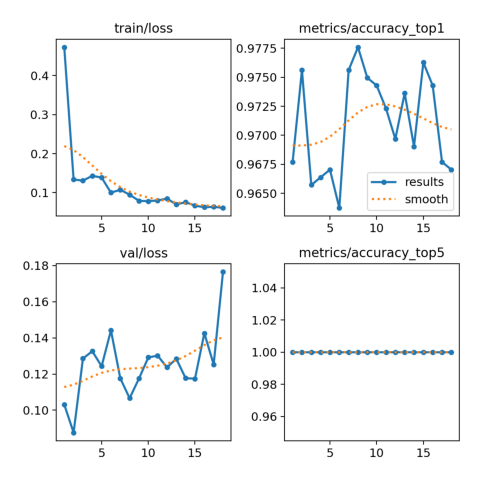

In [5]:
import matplotlib.pyplot as plt
from PIL import Image

# 1. Load the Best Model that was just saved
best_model = YOLO('/kaggle/working/cotton_weed_project/best_model_run/weights/best.pt')

# 2. Run Validation
metrics = best_model.val()

print("\n" + "="*40)
print("📊 FINAL ACCURACY REPORT")
print("="*40)
print(f"🏆 Top-1 Accuracy: {metrics.top1:.2%}")
print(f"🥈 Top-5 Accuracy: {metrics.top5:.2%}")
print("="*40)

# 3. Show Training Graphs (Loss vs Epochs)
# This proves to your professor that the model actually learned
results_path = '/kaggle/working/cotton_weed_project/best_model_run/results.png'
if os.path.exists(results_path):
    plt.figure(figsize=(10, 6))
    plt.imshow(Image.open(results_path))
    plt.axis('off')
    plt.show()


image 1/1 /kaggle/working/cotton_dataset_cls/val/Black Pigweed/DSC03715_JPG.rf.04a52b2f3b96c2d0574f96ddb28fa116.jpg: 224x224 Black Pigweed 1.00, Nutgrass 0.00, Cotton 0.00, 3.3ms
Speed: 6.8ms preprocess, 3.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

🔍 True Class: Black Pigweed
🤖 Predicted: Black Pigweed
📊 Confidence: 1.00


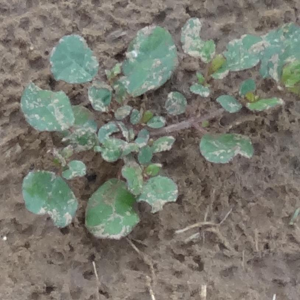

In [9]:
# Pick a random image from the Validation folder
val_root = '/kaggle/working/cotton_dataset_cls/val'
random_class = random.choice(os.listdir(val_root))
random_img = random.choice(os.listdir(os.path.join(val_root, random_class)))
img_path = os.path.join(val_root, random_class, random_img)

# Predict
results = best_model(img_path)

# Display Result
print(f"\n🔍 True Class: {random_class}")
print(f"🤖 Predicted: {results[0].names[results[0].probs.top1]}")
print(f"📊 Confidence: {results[0].probs.top1conf:.2f}")

# Show Image
from IPython.display import display
display(Image.open(img_path).resize((300, 300)))

In [10]:
import shutil
import os
from IPython.display import FileLink

# --- Configuration ---
folder_to_zip = '/kaggle/working/runs'  # The folder where YOLO saves everything
output_filename = 'cotton_weed_project_results'  # Name of your zip file

# 1. Check if the folder exists
if os.path.exists(folder_to_zip):
    print(f"📦 Zipping '{folder_to_zip}'... This might take a few seconds.")
    
    # 2. Create the Zip File
    shutil.make_archive(output_filename, 'zip', folder_to_zip)
    
    print("✅ Zip created successfully!")
    print(f"⬇️ Click the link below to download your full project results:")
    
    # 3. Generate Download Link
    display(FileLink(f'{output_filename}.zip'))
    
else:
    print(f"❌ Error: Could not find '{folder_to_zip}'. Did you run the training step?")

📦 Zipping '/kaggle/working/runs'... This might take a few seconds.
✅ Zip created successfully!
⬇️ Click the link below to download your full project results:


/kaggle/working/cotton_weed_project_results.zip

🚀 Generating Final Project Report...

📂 INPUT SPECIFICATIONS & MODEL INFO
Model Name:        yolov8s-cls.pt
Total Images:      7578
Train Images:      6061
Val Images:        1517
Epochs Trained:    100
Batch Size:        64
Image Resolution:  224x224
Channels:          3 (RGB)
Normalization:     0-1 Scaling (Auto)
Optimizer:         auto

⏳ Running Validation on full dataset to calculate Class-wise Metrics...

📊 OVERALL & CLASS-WISE METRICS
🏆 Overall Accuracy: 98.48%

--- Detailed Report ---
               precision    recall  f1-score   support

Black Pigweed     0.9718    0.9837    0.9777       491
       Cotton     0.9937    0.9859    0.9898       639
     Nutgrass     0.9870    0.9845    0.9858       387

     accuracy                         0.9848      1517
    macro avg     0.9842    0.9847    0.9844      1517
 weighted avg     0.9849    0.9848    0.9849      1517



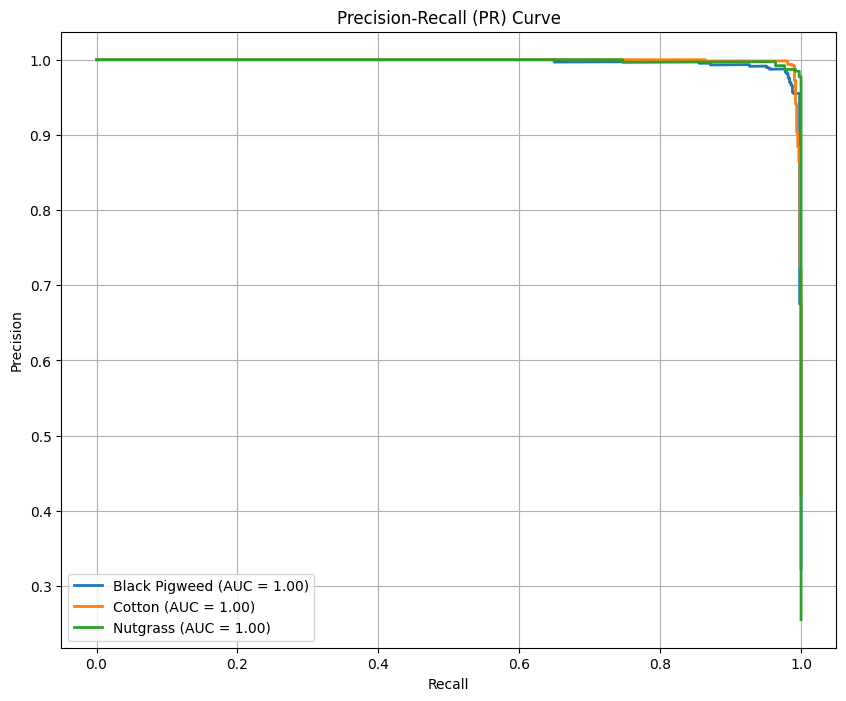

✅ PR Curve saved to 'final_report/PR_Curve.png'

📸 4 RANDOM IMAGE TESTS


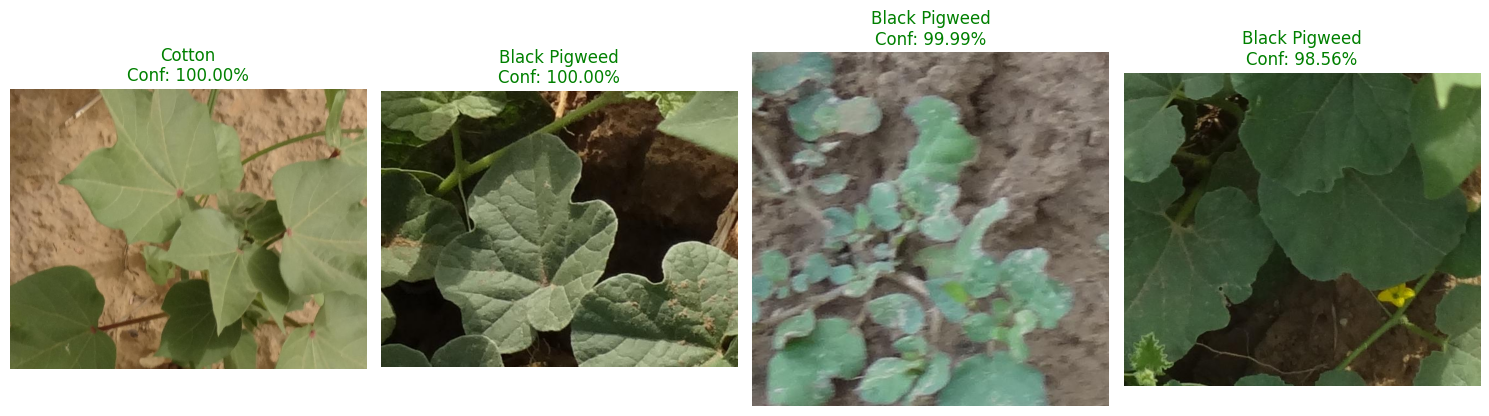

✅ Result images saved in '/kaggle/working/final_report'


In [11]:
import os
import glob
import json
import yaml
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, precision_recall_curve, auc, accuracy_score, confusion_matrix
from ultralytics import YOLO
from PIL import Image
import torch

# --- CONFIGURATION ---
# Path to your dataset and trained model
DATASET_DIR = '/kaggle/working/cotton_classification_data'
MODEL_PATH = '/kaggle/working/cotton_weed_project/best_model_run/weights/best.pt'
ARGS_PATH = '/kaggle/working/cotton_weed_project/best_model_run/args.yaml'
OUTPUT_DIR = '/kaggle/working/final_report'

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("🚀 Generating Final Project Report...")

# 1. GATHER DATASET & TRAINING STATS
train_images = sum([len(files) for r, d, files in os.walk(os.path.join(DATASET_DIR, 'train'))])
val_images = sum([len(files) for r, d, files in os.walk(os.path.join(DATASET_DIR, 'val'))])
total_images = train_images + val_images

# Load training args to get exact Epochs/Batch Size used
with open(ARGS_PATH, 'r') as f:
    args = yaml.safe_load(f)

print("\n" + "="*40)
print("📂 INPUT SPECIFICATIONS & MODEL INFO")
print("="*40)
print(f"Model Name:        {args['model']}")
print(f"Total Images:      {total_images}")
print(f"Train Images:      {train_images}")
print(f"Val Images:        {val_images}")
print(f"Epochs Trained:    {args['epochs']}")
print(f"Batch Size:        {args['batch']}")
print(f"Image Resolution:  {args['imgsz']}x{args['imgsz']}")
print(f"Channels:          3 (RGB)")
print(f"Normalization:     0-1 Scaling (Auto)")
print(f"Optimizer:         {args['optimizer']}")
print("="*40)

# 2. RUN VALIDATION (To get Metrics)
print("\n⏳ Running Validation on full dataset to calculate Class-wise Metrics...")
model = YOLO(MODEL_PATH)
class_names = model.names

# We need to manually predict on validation set to get sklearn metrics
y_true = []
y_pred = []
y_scores = [] # For PR Curve

val_path = os.path.join(DATASET_DIR, 'val')
class_folders = sorted(os.listdir(val_path))

for class_idx, class_name in enumerate(class_folders):
    folder_path = os.path.join(val_path, class_name)
    if not os.path.isdir(folder_path): continue
    
    files = os.listdir(folder_path)
    for file in files:
        img_path = os.path.join(folder_path, file)
        
        # Run inference
        result = model(img_path, verbose=False)[0]
        
        # Store Truth
        y_true.append(class_idx)
        
        # Store Prediction (Class Index)
        y_pred.append(result.probs.top1)
        
        # Store Probabilities (for PR Curve)
        y_scores.append(result.probs.data.cpu().numpy())

# Convert to numpy
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

# 3. PRINT METRICS
print("\n" + "="*40)
print("📊 OVERALL & CLASS-WISE METRICS")
print("="*40)

# Overall Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"🏆 Overall Accuracy: {acc:.2%}")

# Full Classification Report (Precision, Recall, F1 for each class)
report = classification_report(y_true, y_pred, target_names=class_folders, digits=4)
print("\n--- Detailed Report ---")
print(report)

# 4. PLOT PR CURVE (One for each class)
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_folders):
    # Create binary labels for this class
    true_binary = (y_true == i).astype(int)
    score_class = y_scores[:, i]
    
    precision, recall, _ = precision_recall_curve(true_binary, score_class)
    pr_auc = auc(recall, precision)
    
    plt.plot(recall, precision, lw=2, label=f'{class_name} (AUC = {pr_auc:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall (PR) Curve")
plt.legend(loc="best")
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, 'PR_Curve.png'))
plt.show()
print("✅ PR Curve saved to 'final_report/PR_Curve.png'")

# 5. RANDOM INFERENCE DEMO
print("\n" + "="*40)
print("📸 4 RANDOM IMAGE TESTS")
print("="*40)

import random

# Collect all validation images
all_val_images = []
for root, dirs, files in os.walk(val_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.png', '.jpeg')):
            all_val_images.append(os.path.join(root, file))

# Pick 4 random
selected_images = random.sample(all_val_images, 4)

plt.figure(figsize=(15, 5))
for i, img_path in enumerate(selected_images):
    # Run prediction
    res = model(img_path, verbose=False)[0]
    pred_class = res.names[res.probs.top1]
    conf = res.probs.top1conf.item()
    
    # Load Image for display
    img = Image.open(img_path)
    
    # Save individually to working dir
    save_name = f"result_{i}_{pred_class}.jpg"
    res.save(filename=os.path.join(OUTPUT_DIR, save_name))
    
    # Plot
    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{pred_class}\nConf: {conf:.2%}", color='green', fontsize=12)

plt.tight_layout()
plt.show()
print(f"✅ Result images saved in '{OUTPUT_DIR}'")